In [1]:
from typing import Dict, TypedDict, List, Union, Annotated, Sequence
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage, ToolMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool

load_dotenv()


c:\Users\ka448\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


True

In [2]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

@tool
def fix_txt_file(human_message: str, text_file: str) -> str:
    
    """Fix the text file according to the Human message and return the fixed text file."""

    llm = ChatOpenAI(model="gpt-5.4-nano")
    with open(text_file, "r") as f:
        content = f.read()
    result = llm.invoke([
        HumanMessage(content=f"{human_message}\n\nFile content:\n{content}")
    ])
    with open(text_file, "w") as f:
        f.write(result.content)
    return text_file








In [3]:
def agent_node(state: AgentState) -> AgentState:
    system_prompt = SystemMessage(content="You are a helpful assistant that drafts a document until the human is happy with the document")
    response = llm_with_tools.invoke([system_prompt] + list(state["messages"]))
    return {"messages": [response]}

def human_node(state: AgentState) -> AgentState:
    human_m = HumanMessage(content=input("You: "))
    return {"messages": [human_m]}

def decider(state: AgentState):
    last = state["messages"][-1]
    if isinstance(last, HumanMessage):
        return "agent"
    elif isinstance(last, AIMessage) and last.tool_calls:
        return "tool"
    else:
        return "human"


In [4]:
tools = [fix_txt_file]
llm_with_tools = ChatOpenAI(model="gpt-5.4-nano").bind_tools(tools)

main_graph = StateGraph(AgentState)
main_graph.add_node("Agent", agent_node)
main_graph.add_node("Human", human_node)
main_graph.add_node("Tool", ToolNode(tools))

main_graph.set_entry_point("Human")
main_graph.add_conditional_edges("Human", decider, {"agent": "Agent"})
main_graph.add_conditional_edges("Agent", decider, {"tool": "Tool", "human": "Human"})
main_graph.add_edge("Tool", "Agent")

x = main_graph.compile()


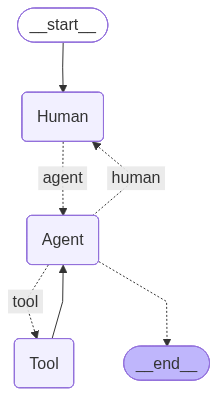

In [5]:
x

In [ ]:
x.invoke({"messages": []})